Total satellite images found: 544
Sample image: ../satellite images\2020\april\2020-04-01.png


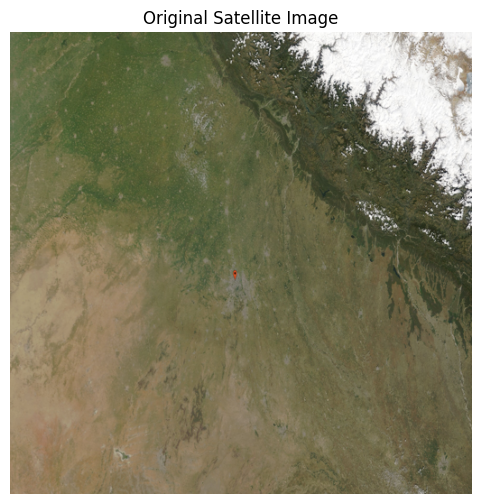

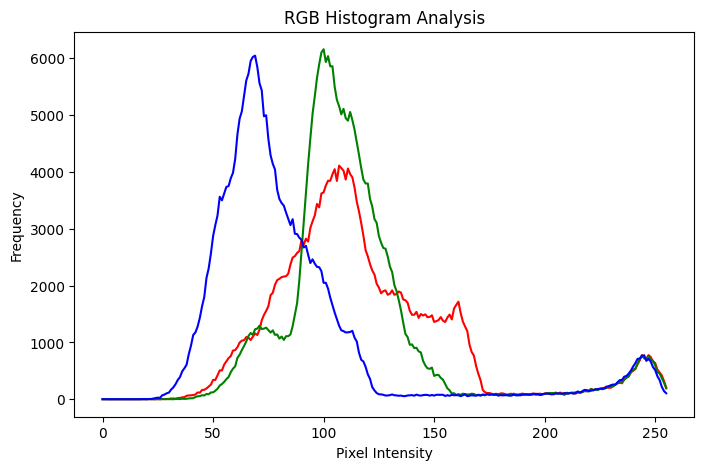

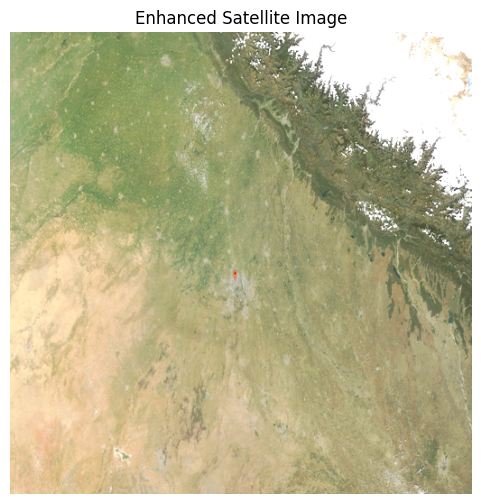

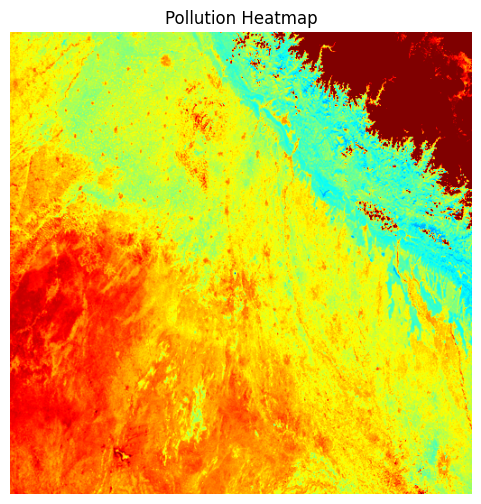

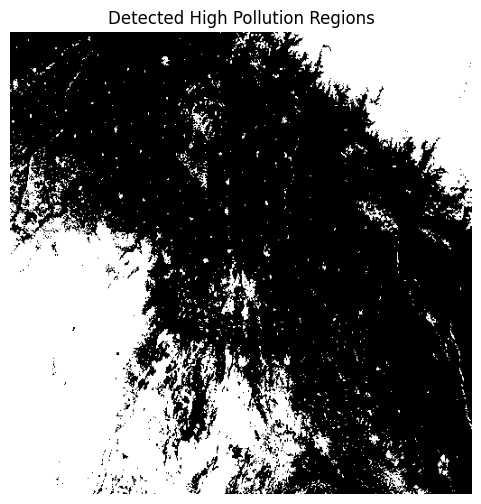

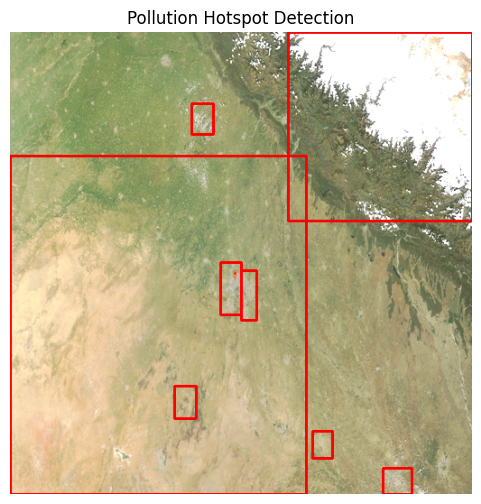

Estimated Pollution Coverage: 34.44 %


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# LOAD ONE SATELLITE IMAGE
# =========================
base_folder = "../satellite images"

image_paths = []

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, file))

print("Total satellite images found:", len(image_paths))

# pick sample image
sample_path = image_paths[0]
print("Sample image:", sample_path)

# =========================
# LOAD IMAGE
# =========================
img = Image.open(sample_path).convert("RGB")
img = img.resize((512, 512))

img_np = np.array(img)

plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.title("Original Satellite Image")
plt.axis("off")
plt.show()

# =========================
# RGB HISTOGRAM ANALYSIS
# =========================
colors = ('r', 'g', 'b')

plt.figure(figsize=(8,5))

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_np], [i], None, [256], [0,256])
    plt.plot(hist, color=color)

plt.title("RGB Histogram Analysis")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# =========================
# IMAGE ENHANCEMENT
# =========================
enhanced = cv2.convertScaleAbs(img_np, alpha=1.4, beta=20)

plt.figure(figsize=(6,6))
plt.imshow(enhanced)
plt.title("Enhanced Satellite Image")
plt.axis("off")
plt.show()

# =========================
# POLLUTION HEATMAP
# =========================
gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)

heatmap = cv2.applyColorMap(gray, cv2.COLORMAP_JET)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
plt.title("Pollution Heatmap")
plt.axis("off")
plt.show()

# =========================
# HOTSPOT DETECTION
# =========================
threshold = 180

_, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("Detected High Pollution Regions")
plt.axis("off")
plt.show()

# =========================
# CONTOUR HOTSPOTS
# =========================
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = enhanced.copy()

for cnt in contours:
    if cv2.contourArea(cnt) > 100:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x,y), (x+w,y+h), (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(output)
plt.title("Pollution Hotspot Detection")
plt.axis("off")
plt.show()

# =========================
# POLLUTION PERCENTAGE
# =========================
polluted_pixels = np.sum(mask == 255)
total_pixels = mask.size

pollution_percent = (polluted_pixels / total_pixels) * 100

print("Estimated Pollution Coverage:", round(pollution_percent, 2), "%")